Columns in Dataset:
['Student_ID', 'Student_Name', 'Study_Hours', 'Attendance', 'Assignment_Score', 'Final_Marks', 'Result']

========== REGRESSION ==========
R² Score: 0.8565784063748548
MSE: 24.92245623377605


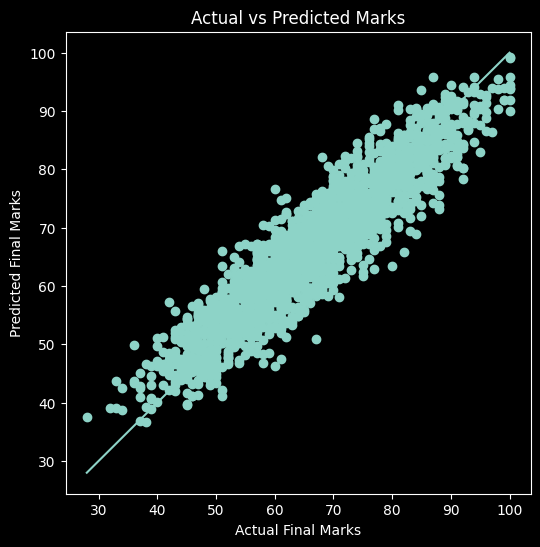


Predicted Final Marks:
46.69

========== CLASSIFICATION ==========
Accuracy: 0.9015


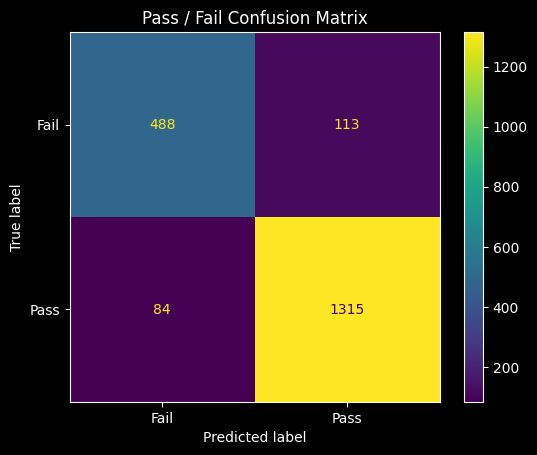


Pass / Fail Prediction:
FAIL


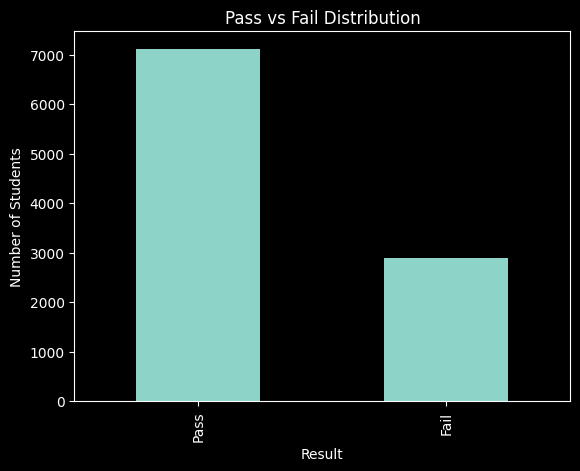

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# ==========================
# LOAD EXCEL DATASET
# ==========================
data = pd.read_excel("student_marks_10000 (1).xlsx")

print("Columns in Dataset:")
print(data.columns.tolist())

# ==========================
# CONVERT PASS/FAIL TO 0/1
# ==========================
le = LabelEncoder()
data["Pass"] = le.fit_transform(data["Result"])

# ==================================================
# REGRESSION
# Predict Final Marks
# ==================================================
X_reg = data[
    ["Study_Hours", "Attendance", "Assignment_Score"]
]

y_reg = data["Final_Marks"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

reg_model = LinearRegression()

reg_model.fit(X_train_reg, y_train_reg)

reg_predictions = reg_model.predict(X_test_reg)

print("\n========== REGRESSION ==========")
print("R² Score:", r2_score(y_test_reg, reg_predictions))
print("MSE:", mean_squared_error(y_test_reg, reg_predictions))

# ==================================================
# ACTUAL VS PREDICTED GRAPH
# ==================================================
plt.figure(figsize=(6, 6))

plt.scatter(y_test_reg, reg_predictions)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Marks")

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()]
)

plt.show()

# ==================================================
# NEW STUDENT MARKS PREDICTION
# ==================================================
new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [85],
    "Assignment_Score": [8]
})

predicted_marks = reg_model.predict(new_student)

print("\nPredicted Final Marks:")
print(round(predicted_marks[0], 2))

# ==================================================
# CLASSIFICATION
# Predict Pass/Fail
# ==================================================
X_cls = data[
    ["Study_Hours", "Attendance", "Assignment_Score"]
]

y_cls = data["Pass"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)

cls_model = LogisticRegression(max_iter=1000)

cls_model.fit(X_train_cls, y_train_cls)

cls_predictions = cls_model.predict(X_test_cls)

print("\n========== CLASSIFICATION ==========")
print("Accuracy:", accuracy_score(y_test_cls, cls_predictions))

# ==================================================
# CONFUSION MATRIX
# ==================================================
cm = confusion_matrix(y_test_cls, cls_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()

plt.title("Pass / Fail Confusion Matrix")

plt.show()

# ==================================================
# PASS / FAIL PREDICTION
# ==================================================
prediction = cls_model.predict(new_student)

print("\nPass / Fail Prediction:")

if prediction[0] == 1:
    print("PASS")
else:
    print("FAIL")

# ==================================================
# CHART: PASS VS FAIL DISTRIBUTION
# ==================================================
data["Result"].value_counts().plot(
    kind="bar"
)

plt.title("Pass vs Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()